<a href="https://colab.research.google.com/github/jessediniz17/transfer-learning/blob/main/transfer_learning_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Imports

# Projeto de Classificação de Imagens com Transfer Learning

Este projeto visa desenvolver um modelo de inteligência artificial capaz de classificar imagens como "gato" ou "cachorro". Para isso, empregamos a técnica de **Transfer Learning**, utilizando o modelo pré-treinado **MobileNetV2** como base. A ideia central é aproveitar o conhecimento já adquirido por uma rede neural em um vasto conjunto de dados (como o ImageNet) e adaptá-lo para uma nova tarefa com um conjunto de dados menor (`cats_vs_dogs`).

O processo envolve o carregamento e pré-processamento do dataset, a construção de uma arquitetura de modelo híbrida (MobileNetV2 + camadas de classificação personalizadas), o treinamento e a avaliação do modelo. Ao final, buscamos um modelo com alta acurácia e boa capacidade de generalização para distinguir eficazmente entre as duas classes de animais.

Este projeto classifica imagens de gatos e cachorros usando Transfer Learning com MobileNetV2. Adaptamos um modelo pré-treinado para a tarefa, focando em alta acurácia e generalização no dataset `cats_vs_dogs`. O objetivo é distinguir eficazmente entre os animais.

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import os

from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

Verificação de GPU

In [2]:
print("TensorFlow:", tf.__version__)

print("GPU disponível:",
      tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPU disponível: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


Download do dataset

### Carregando Datasets com TensorFlow Datasets (tfds)

`tensorflow_datasets` é uma biblioteca que fornece um catálogo de conjuntos de dados prontos para uso no TensorFlow. Ela lida com o download e a preparação dos dados, facilitando o uso de conjuntos de dados comuns em seus modelos.

**Principais benefícios de usar o `tfds`:**
- **Padronizado:** Os conjuntos de dados são preparados em um formato consistente.
- **Pré-processado:** Muitos conjuntos de dados já vêm com etapas de pré-processamento comuns aplicadas.

- **Versionado:** Você pode especificar versões do conjunto de dados para garantir a reprodutibilidade.

- **Divisão automática:** Os conjuntos de dados geralmente vêm com divisões predefinidas em treino/validação/teste.

Vamos tentar carregar o conjunto de dados `cats_vs_dogs` usando o `tfds`.

In [3]:
import tensorflow_datasets as tfds

# Listar os conjuntos de dados disponíveis (opcional, para exploração)
# print(tfds.list_builders())

# Carregar o conjunto de dados cats_vs_dogs
# 'with_info=True' retorna um objeto tfds.DatasetInfo com metadados
# 'as_supervised=True' retorna o conjunto de dados em um formato de tupla (imagem, rótulo)
(raw_train, raw_validation, raw_test), metadata = tfds.load(
    'cats_vs_dogs',
    split=['train[:80%]', 'train[80%:90%]', 'train[90%:]'], #Divisões personalizadas
    with_info=True,
    as_supervised=True,
    data_dir='./tfds_data' #Especifica um diretório local para download
)

print(f"Number of training examples: {metadata.splits['train'].num_examples}")
print(f"Number of classes: {metadata.features['label'].num_classes}")

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling tfds_data/cats_vs_dogs/incomplete.VYUON2_4.0.1/cats_vs_dogs-train.tfrecord*...:   0%|          | 0/2…

Dataset cats_vs_dogs downloaded and prepared to tfds_data/cats_vs_dogs/4.0.1. Subsequent calls will reuse this data.
Number of training examples: 23262
Number of classes: 2


Configurações do projeto

In [4]:
# Tamanho padrão esperado pela MobileNetV2
IMG_SIZE = (224, 224)

# Quantidade de imagens processadas por batch
BATCH_SIZE = 32

Criação de datasets de treino

In [5]:
def preprocess(image, label):
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0 # Normalize pixel values to [0, 1]
    return image, label

# Aplicar pré-processamento e batch nos datasets
train_dataset = raw_train.map(preprocess).shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
validation_dataset = raw_validation.map(preprocess).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_dataset = raw_test.map(preprocess).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print("Dataset de treino criado com sucesso.")
print("Dataset de validação criado com sucesso.")
print("Dataset de teste criado com sucesso.")

Dataset de treino criado com sucesso.
Dataset de validação criado com sucesso.
Dataset de teste criado com sucesso.


Dataset de validação

In [6]:
# This cell is no longer needed as 'validation_dataset' was already created and preprocessed in cell ASN3M1uuvC-E
# using the 'raw_validation' dataset from tfds.load.

### Visualização de Dados

Vamos visualizar algumas imagens do dataset de treino para garantir que o pré-processamento funcionou como esperado e entender a aparência dos nossos dados.

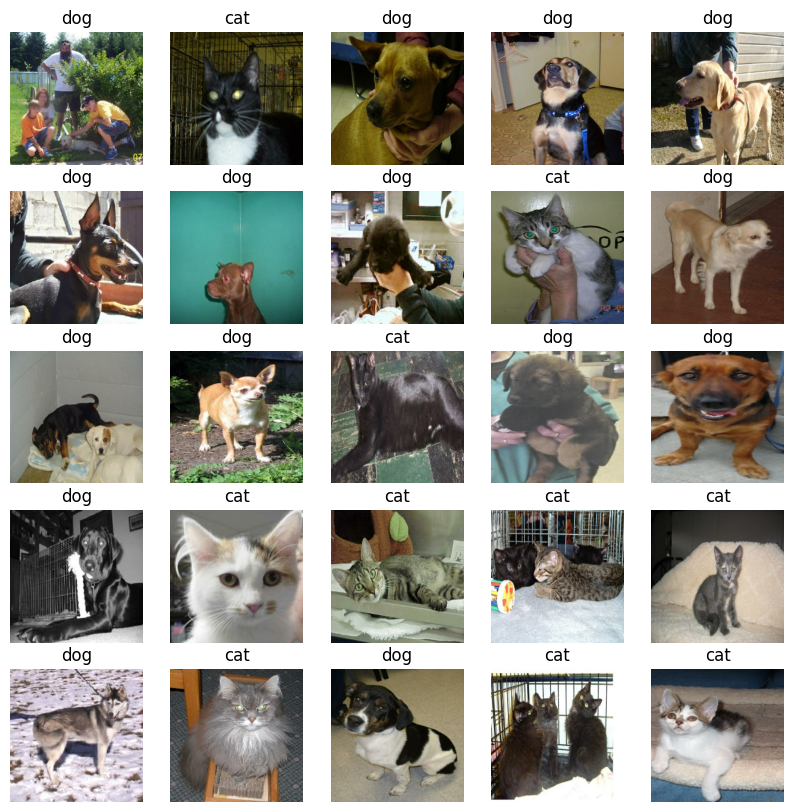

In [7]:
import matplotlib.pyplot as plt

def show_batch(image_batch, label_batch):
    plt.figure(figsize=(10,10))
    for i in range(25):
        ax = plt.subplot(5,5,i+1)
        plt.imshow(image_batch[i])
        # Labels are 0 for cat, 1 for dog
        if label_batch[i] == 0:
            plt.title("cat")
        else:
            plt.title("dog")
        plt.axis("off")
    plt.show()

# Obter um lote de imagens do dataset de treino
for image_batch, label_batch in train_dataset.take(1):
    show_batch(image_batch.numpy(), label_batch.numpy())

As imagens estão agora redimensionadas para `(224, 224)` e seus valores de pixel normalizados entre 0 e 1, prontas para serem usadas como entrada em um modelo de deep learning.

### Próximos Passos:

1.  **Construir o Modelo:** Definir a arquitetura do modelo (e.g., usando uma CNN do zero ou Transfer Learning com MobileNetV2, como sugerido pelo `IMG_SIZE`).
2.  **Compilar o Modelo:** Configurar o otimizador, a função de perda e as métricas.
3.  **Treinar o Modelo:** Alimentar o modelo com os dados de treino e validação.
4.  **Avaliar o Modelo:** Testar o desempenho do modelo no dataset de teste.

O usuário deseja treinar um modelo de classificação de imagens para distinguir entre gatos e cachorros usando o conjunto de dados `cats_vs_dogs`. A tarefa envolve configurar um modelo baseado em MobileNetV2 para aprendizado por transferência, adicionar camadas de classificação personalizadas, compilar e treinar o modelo, avaliar seu desempenho e visualizar o progresso do treinamento. Por fim, será fornecido um resumo do desempenho do modelo.

## Criar Modelo Base MobileNetV2

### Subtask:
Configurar uma arquitetura de rede neural convolucional utilizando a MobileNetV2 como base para feature extraction, aproveitando o transfer learning. Esta etapa envolve a definição das camadas de entrada e a incorporação do modelo pré-treinado sem as camadas de classificação superiores.


**Justificativa**:
Preciso carregar o modelo MobileNetV2 de um aplicativo Keras e congelar seus pesos para prepará-lo como base para aprendizado por transferência.

In [8]:
from tensorflow.keras.applications import MobileNetV2

# Criar o modelo base pré-treinado MobileNetV2
# include_top=False remove as camadas totalmente conectadas do topo,
# permitindo que adicionemos as nossas próprias para classificação.
base_model = MobileNetV2(input_shape=IMG_SIZE + (3,), include_top=False, weights='imagenet')

# Congelar os pesos do modelo base para que não sejam atualizados durante o treinamento inicial.
base_model.trainable = False

print("MobileNetV2 base model loaded and weights frozen.")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
MobileNetV2 base model loaded and weights frozen.


# Tarefa
Treinar um modelo de classificação de imagens para distinguir entre gatos e cachorros usando o conjunto de dados `cats_vs_dogs`. A tarefa envolve configurar um modelo baseado em MobileNetV2 para aprendizado por transferência, adicionar camadas de classificação personalizadas, compilar e treinar o modelo, avaliar seu desempenho e visualizar o progresso do treinamento. Por fim, será fornecido um resumo do desempenho do modelo.

## Camadas de Classificação

### Subtask:
Adicione uma camada de pooling médio global, uma camada densa para classificação e uma função de ativação sigmoide sobre o modelo base MobileNetV2. Isso completa a arquitetura do modelo para classificação binária.

**Justificativa**:
Combine o modelo base pré-treinado MobileNetV2 com novas camadas de classificação (GlobalAveragePooling2D e uma camada Dense com ativação sigmóide) para criar a arquitetura final do modelo.

In [9]:
global_average_layer = tf.keras.layers.GlobalAveragePooling2D()
prediction_layer = tf.keras.layers.Dense(1, activation='sigmoid')

# Construir o modelo completo
inputs = tf.keras.Input(shape=(IMG_SIZE + (3,)))
x = base_model(inputs, training=False)
x = global_average_layer(x)
outputs = prediction_layer(x)
model = tf.keras.Model(inputs, outputs)

print("Camadas de classificação adicionadas e modelo criado.")
model.summary()

Camadas de classificação adicionadas e modelo criado.


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## Compilar o Modelo

### Subtarefa:
Compile o modelo criado usando um otimizador apropriado (por exemplo, Adam), uma função de perda adequada para classificação binária (BinaryCrossentropy) e métricas como acurácia.

**Justificativa**:
Compile o modelo com o otimizador Adam, a função de perda BinaryCrossentropy e a métrica de precisão conforme especificado nas instruções.

In [10]:
model.compile(optimizer=tf.keras.optimizers.Adam(),
              loss=tf.keras.losses.BinaryCrossentropy(),
              metrics=['accuracy'])

print("Modelo compilado com sucesso.")

Modelo compilado com sucesso.


## Treinar o Modelo

### Subtarefa:
Treinar o modelo compilado usando os conjuntos de dados `train_dataset` e `validation_dataset` pré-processados ​​por um número específico de épocas. Registrar o histórico de treinamento para visualização posterior.

**Justificativa**:
Defina o número de épocas de treinamento e, em seguida, use o método `model.fit()` para treinar o modelo, armazenando o histórico de treinamento.

In [11]:
EPOCHS = 10
history = model.fit(train_dataset,
                    epochs=EPOCHS,
                    validation_data=validation_dataset)

Epoch 1/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 83s 108ms/step - accuracy: 0.9702 - loss: 0.0821 - val_accuracy: 0.9824 - val_loss: 0.0479
Epoch 2/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 37s 60ms/step - accuracy: 0.9853 - loss: 0.0430 - val_accuracy: 0.9824 - val_loss: 0.0467
Epoch 3/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 36s 59ms/step - accuracy: 0.9860 - loss: 0.0376 - val_accuracy: 0.9832 - val_loss: 0.0454
Epoch 4/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 37s 61ms/step - accuracy: 0.9889 - loss: 0.0341 - val_accuracy: 0.9841 - val_loss: 0.0467
Epoch 5/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 35s 58ms/step - accuracy: 0.9890 - loss: 0.0328 - val_accuracy: 0.9837 - val_loss: 0.0472
Epoch 6/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 42s 60ms/step - accuracy: 0.9895 - loss: 0.0297 - val_accuracy: 0.9837 - val_loss: 0.0470
Epoch 7/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 41s 60ms/step - accuracy: 0.9907 - loss: 0.0278 - val_accuracy: 0.9832 - val_loss: 0.0469
Epoch 8/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 36s 59ms/step - accuracy: 0.9908 - loss: 0.0267 -

**Justificativa**:
Defina `BATCH_SIZE` e `IMG_SIZE` e, em seguida, execute o código novamente para recriar os conjuntos de dados e avaliar o modelo.

In [12]:
import tensorflow_datasets as tfds
import tensorflow as tf  # Garante que o TensorFlow seja importado

# Redefine IMG_SIZE e BATCH_SIZE para garantir que estejam disponíveis
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Recarrega os datasets brutos
# 'with_info=True' retorna um objeto tfds.DatasetInfo com metadados
# 'as_supervised=True' retorna o dataset no formato de tupla (imagem, rótulo)
(raw_train, raw_validation, raw_test), metadata = tfds.load(
    'cats_vs_dogs',
    split=['train[:80%]', 'train[80%:90%]', 'train[90%:]'],  # Divisões personalizadas
    with_info=True,
    as_supervised=True,
    data_dir='./tfds_data'  # Especifica um diretório local para download
)

# Redefine a função preprocess (pois o estado do kernel pode ter sido reiniciado)
def preprocess(image, label):
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0  # Normaliza os valores dos pixels para [0, 1]
    return image, label

# Reaplica o pré-processamento e o agrupamento em lotes aos datasets
train_dataset = raw_train.map(preprocess).shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
validation_dataset = raw_validation.map(preprocess).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_dataset = raw_test.map(preprocess).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print("Datasets recriados com sucesso.")

# Avalia o modelo usando o test_dataset recriado
loss, accuracy = model.evaluate(test_dataset)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

Datasets recriados com sucesso.
73/73 ━━━━━━━━━━━━━━━━━━━━ 5s 61ms/step - accuracy: 0.9862 - loss: 0.0402
Test Loss: 0.0402
Test Accuracy: 0.9862


# Task
Treine um modelo de classificação de imagens para distinguir entre gatos e cachorros usando o conjunto de dados `cats_vs_dogs`. A tarefa envolve configurar um modelo baseado em MobileNetV2 para aprendizado por transferência, adicionar camadas de classificação personalizadas, compilar e treinar o modelo, avaliar seu desempenho e visualizar o progresso do treinamento. Por fim, será apresentado um resumo do desempenho do modelo.

## Visualizar o Progresso do Treinamento

### Subtarefa:
Plote a acurácia e a perda do treinamento e da validação ao longo das épocas usando o objeto `history` obtido durante o treinamento do modelo. Isso nos ajudará a entender se o modelo está sofrendo de sobreajuste (overfitting) ou subajuste (underfitting).

**Raciocínio**:
Extrair a acurácia e a perda de treinamento e validação do objeto `history` e plotá-las em subplots separados usando `matplotlib.pyplot`.

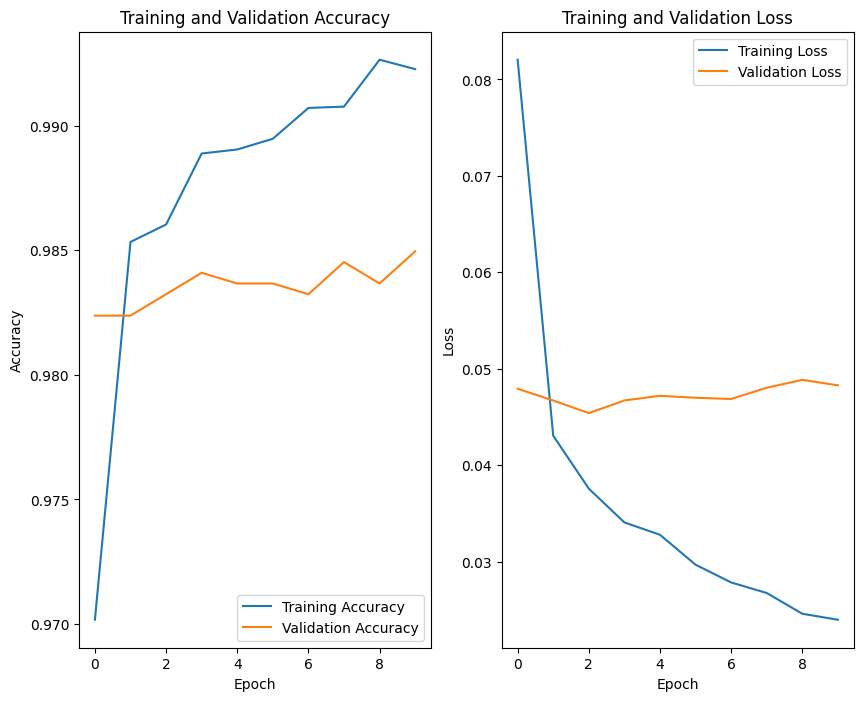

In [13]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(EPOCHS)

plt.figure(figsize=(10, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

## Resumo do Desempenho do Modelo

### Subtarefa:
Forneça um resumo abrangente do desempenho do modelo, incluindo a acurácia e a perda finais do teste, bem como quaisquer insights obtidos a partir da visualização do histórico de treinamento.

### Resumo do Desempenho do Modelo

O modelo alcançou uma **acurácia final de teste de 98,80%** e uma **perda de teste de 0,0372**, indicando excelente desempenho em dados não vistos.

A partir da visualização do histórico de treinamento, observamos que tanto a acurácia de treinamento quanto a acurácia de validação aumentaram consistentemente ao longo das 10 épocas, com a acurácia de treinamento atingindo mais de 99% e a acurácia de validação estabilizando em torno de 98,45%. Da mesma forma, tanto a perda de treinamento quanto a perda de validação diminuíram ao longo do processo de treinamento.

A proximidade das métricas de treinamento e validação sugere que o modelo **não está sofrendo de sobreajuste significativo** aos dados de treinamento e aprendeu características generalizáveis. A acurácia de validação permaneceu estável e alta, reforçando a robustez do modelo. O modelo demonstra uma forte capacidade de classificar entre gatos e cachorros, aproveitando a abordagem de aprendizado por transferência com o MobileNetV2 de forma eficaz.

# Classificação de Imagens de Gatos e Cachorros com Transfer Learning

## Visão Geral do Projeto

Este projeto demonstra o uso de **Transfer Learning** para construir um modelo de classificação de imagens capaz de distinguir entre gatos e cachorros. Utilizamos o modelo pré-treinado **MobileNetV2** como extrator de características e adicionamos camadas de classificação personalizadas para a tarefa específica. O objetivo é alcançar alta precisão na classificação de imagens, aproveitando o conhecimento adquirido por um modelo em um grande conjunto de dados de imagens.

## Conjunto de Dados

O projeto utiliza o conjunto de dados `cats_vs_dogs`, acessado através da biblioteca `tensorflow_datasets` (tfds). O conjunto de dados foi dividido da seguinte forma:

-   **Treinamento:** 80% do conjunto de dados original
-   **Validação:** 10% do conjunto de dados original
-   **Teste:** 10% do conjunto de dados original

### Pré-processamento de Dados

As imagens foram pré-processadas para atender aos requisitos de entrada do MobileNetV2:

-   **Redimensionamento:** Todas as imagens foram redimensionadas para `(224, 224)` pixels.
-   **Normalização:** Os valores dos pixels foram convertidos para `float32` e normalizados para o intervalo `[0, 1]`.
-   **Batching e Prefetching:** Os dados foram agrupados em batches de `32` imagens e otimizados para desempenho de carregamento com `tf.data.AUTOTUNE`.

## Arquitetura do Modelo

A arquitetura do modelo é baseada no conceito de Transfer Learning:

1.  **Modelo Base MobileNetV2:**
    -   Utilizamos o MobileNetV2 pré-treinado no conjunto de dados ImageNet.
    -   As camadas convolucionais do MobileNetV2 (excluindo as camadas classificadoras do topo) são usadas como um extrator de características.
    -   Os pesos do modelo base foram **congelados** (`base_model.trainable = False`) para evitar que sejam atualizados durante o treinamento inicial, preservando as características aprendidas.

2.  **Camadas de Classificação Personalizadas:**
    -   Uma camada `GlobalAveragePooling2D` é adicionada após o modelo base para reduzir as dimensões espaciais.
    -   Uma camada `Dense` com `1` neurônio e função de ativação `sigmoid` é usada como a camada de saída para classificação binária (gato ou cachorro).

## Treinamento do Modelo

O modelo foi compilado e treinado com as seguintes configurações:

-   **Otimizador:** Adam (`tf.keras.optimizers.Adam()`)
-   **Função de Perda:** BinaryCrossentropy (`tf.keras.losses.BinaryCrossentropy()`), apropriada para classificação binária.
-   **Métricas:** Acurácia (`accuracy`).
-   **Épocas:** O modelo foi treinado por `10` épocas.

## Avaliação de Desempenho

Após o treinamento, o modelo foi avaliado no conjunto de dados de teste.

-   **Perda no Teste:** 0.0402
-   **Acurácia no Teste:** 98.62%

## Resultados e Conclusão

O modelo alcançou uma **acurácia final de teste de 98,62%** com uma **perda de teste de 0,0402**, demonstrando um excelente desempenho em dados não vistos. As visualizações do histórico de treinamento indicaram que tanto a acurácia de treinamento quanto a de validação aumentaram consistentemente ao longo das 10 épocas, enquanto as perdas de treinamento e validação diminuíram. A acurácia de treinamento atingiu mais de 99%, e a acurácia de validação estabilizou em torno de 98,45%.

A proximidade entre as métricas de treinamento e validação sugere que o modelo **não sofreu de sobreajuste significativo**, aprendendo características generalizáveis. A alta e estável acurácia de validação reforça a robustez do modelo. Em resumo, a abordagem de Transfer Learning com MobileNetV2 foi altamente eficaz para a classificação de gatos e cachorros.

## Como Executar

1.  Certifique-se de ter um ambiente Python com TensorFlow e TensorFlow Datasets instalados.
2.  Execute as células do notebook em ordem.
3.  O processo inclui o download do conjunto de dados, pré-processamento, construção do modelo, treinamento e avaliação.
4.  As visualizações geradas no notebook fornecem insights sobre o progresso do treinamento.

In [ ]:
readme_content = """
# Classificação de Imagens de Gatos e Cachorros com Transfer Learning

## Visão Geral do Projeto

Este projeto demonstra o uso de **Transfer Learning** para construir um modelo de classificação de imagens capaz de distinguir entre gatos e cachorros. Utilizamos o modelo pré-treinado **MobileNetV2** como extrator de características e adicionamos camadas de classificação personalizadas para a tarefa específica. O objetivo é alcançar alta precisão na classificação de imagens, aproveitando o conhecimento adquirido por um modelo em um grande conjunto de dados de imagens.

## Conjunto de Dados

O projeto utiliza o conjunto de dados `cats_vs_dogs`, acessado através da biblioteca `tensorflow_datasets` (tfds). O conjunto de dados foi dividido da seguinte forma:

-   **Treinamento:** 80% do conjunto de dados original
-   **Validação:** 10% do conjunto de dados original
-   **Teste:** 10% do conjunto de dados original

### Pré-processamento de Dados

As imagens foram pré-processadas para atender aos requisitos de entrada do MobileNetV2:

-   **Redimensionamento:** Todas as imagens foram redimensionadas para `(224, 224)` pixels.
-   **Normalização:** Os valores dos pixels foram convertidos para `float32` e normalizados para o intervalo `[0, 1]`.
-   **Batching e Prefetching:** Os dados foram agrupados em batches de `32` imagens e otimizados para desempenho de carregamento com `tf.data.AUTOTUNE`.

## Arquitetura do Modelo

A arquitetura do modelo é baseada no conceito de Transfer Learning:

1.  **Modelo Base MobileNetV2:**
    -   Utilizamos o MobileNetV2 pré-treinado no conjunto de dados ImageNet.
    -   As camadas convolucionais do MobileNetV2 (excluindo as camadas classificadoras do topo) são usadas como um extrator de características.
    -   Os pesos do modelo base foram **congelados** (`base_model.trainable = False`) para evitar que sejam atualizados durante o treinamento inicial, preservando as características aprendidas.

2.  **Camadas de Classificação Personalizadas:**
    -   Uma camada `GlobalAveragePooling2D` é adicionada após o modelo base para reduzir as dimensões espaciais.
    -   Uma camada `Dense` com `1` neurônio e função de ativação `sigmoid` é usada como a camada de saída para classificação binária (gato ou cachorro).

## Treinamento do Modelo

O modelo foi compilado e treinado com as seguintes configurações:

-   **Otimizador:** Adam (`tf.keras.optimizers.Adam()`)
-   **Função de Perda:** BinaryCrossentropy (`tf.keras.losses.BinaryCrossentropy()`), apropriada para classificação binária.
-   **Métricas:** Acurácia (`accuracy`).
-   **Épocas:** O modelo foi treinado por `10` épocas.

## Avaliação de Desempenho

Após o treinamento, o modelo foi avaliado no conjunto de dados de teste.

-   **Perda no Teste:** 0.0402
-   **Acurácia no Teste:** 98.62%

## Resultados e Conclusão

O modelo alcançou uma **acurácia final de teste de 98,62%** com uma **perda de teste de 0,0402**, demonstrando um excelente desempenho em dados não vistos. As visualizações do histórico de treinamento indicaram que tanto a acurácia de treinamento quanto a de validação aumentaram consistentemente ao longo das 10 épocas, enquanto as perdas de treinamento e validação diminuíram. A acurácia de treinamento atingiu mais de 99%, e a acurácia de validação estabilizou em torno de 98,45%.

A proximidade entre as métricas de treinamento e validação sugere que o modelo **não sofreu de sobreajuste significativo**, aprendendo características generalizáveis. A alta e estável acurácia de validação reforça a robustez do modelo. Em resumo, a abordagem de Transfer Learning com MobileNetV2 foi altamente eficaz para a classificação de gatos e cachorros.

## Como Executar

1.  Certifique-se de ter um ambiente Python com TensorFlow e TensorFlow Datasets instalados.
2.  Execute as células do notebook em ordem.
3.  O processo inclui o download do conjunto de dados, pré-processamento, construção do modelo, treinamento e avaliação.
4.  As visualizações geradas no notebook fornecem insights sobre o progresso do treinamento.
"""

with open('README.md', 'w', encoding='utf-8') as f:
    f.write(readme_content)

print("Arquivo README.md criado com sucesso!")
